## STEP 1: Import Libraries

In [91]:
# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

# ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## STEP 2: Load Dataset

In [92]:


df = pd.read_csv("Cleaned Dataset.csv")

# Preview data
df.head()

,id,screen_name,description_clean,location_clean,followers_scaled,friends_scaled,favourites_scaled,verified,label,lang
0,7.874060e+17,best_in_dumbest,blame xaiax inspired by makinginvisible using ...,unknown,7.371489,1.609438,1.609438,0,1,en
1,7.962160e+17,CJRubinPhoto,photographing the american west since 1980 i s...,estados unidos,6.758095,6.781058,6.285998,0,0,en
2,8.759500e+17,SVGEGENT,scruffy looking nerf herder and twitch broadca...,los angeles ca,5.153292,6.388561,8.104099,0,0,en
3,7.561200e+17,TinkerVHELPK5,wife godmother friend feline fanatic assistant...,birmingham al,6.249975,6.452049,9.040026,0,0,en
4,4.647813e+08,JoleonLescott,loan coach at mancity aspiring dj,england united kingdom,13.532722,4.762174,4.488636,0,0,en


In [93]:
# Check structure
df.info()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37434 entries, 0 to 37433
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 37434 non-null  float64
 1   screen_name        37434 non-null  object 
 2   description_clean  28595 non-null  object 
 3   location_clean     36782 non-null  object 
 4   followers_scaled   37434 non-null  float64
 5   friends_scaled     37434 non-null  float64
 6   favourites_scaled  37434 non-null  float64
 7   verified           37434 non-null  int64  
 8   label              37434 non-null  int64  
 9   lang               37434 non-null  object 
dtypes: float64(4), int64(2), object(4)
memory usage: 2.9+ MB


,0
id,0
screen_name,0
description_clean,8839
location_clean,652
followers_scaled,0
friends_scaled,0
favourites_scaled,0
verified,0
label,0
lang,0


## STEP 3: Basic Cleaning

In [94]:
TEXT_COLUMN = 'description_clean'

# Fill missing text with empty string
df[TEXT_COLUMN] = df[TEXT_COLUMN].fillna("")

In [95]:
# Fill location (optional)
df['location_clean'] = df['location_clean'].fillna("unknown")

# Fill numeric columns
numeric_cols = ['followers_scaled', 'friends_scaled', 'favourites_scaled', 'verified', 'label']

df[numeric_cols] = df[numeric_cols].fillna(0)

In [96]:
# removing unnecessary columns
df = df.drop(columns=['id'])  # not useful for ML

In [97]:
df.isnull().sum()

,0
screen_name,0
description_clean,0
location_clean,0
followers_scaled,0
friends_scaled,0
favourites_scaled,0
verified,0
label,0
lang,0


## STEP 4: FEATURE ENGINEERING

### BEHAVIORAL FEATURES

In [98]:
# Follower-Friend Ratio
df['follower_friend_ratio'] = df['followers_scaled'] / (df['friends_scaled'] + 1)

# Engagement Score (likes/favorites vs followers)
df['engagement_score'] = df['favourites_scaled'] / (df['followers_scaled'] + 1)

# Social Balance Index
df['social_balance'] = df['followers_scaled'] - df['friends_scaled']

# Bio Length (important behavioral signal)
df['bio_length'] = df['description_clean'].apply(len)

# Empty Profile Indicator
df['empty_profile'] = df['description_clean'].apply(lambda x: 1 if x.strip() == "" else 0)

###  USERNAME FEATURES

In [99]:
# Username length
df['username_length'] = df['screen_name'].apply(len)

# Number of digits in username (bots often use numbers)
df['digit_count'] = df['screen_name'].apply(lambda x: sum(c.isdigit() for c in x))

### SENTIMENT ANALYSIS

In [100]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['description_clean'].apply(get_sentiment)

### SPAM WORD COUNT

In [101]:
spam_words = ['free', 'win', 'offer', 'click', 'buy', 'money']

def count_spam_words(text):
    text = text.lower()
    return sum(word in text for word in spam_words)

df['spam_count'] = df['description_clean'].apply(count_spam_words)

In [102]:
df.head()

,screen_name,description_clean,location_clean,followers_scaled,friends_scaled,favourites_scaled,verified,label,lang,follower_friend_ratio,engagement_score,social_balance,bio_length,empty_profile,username_length,digit_count,sentiment,spam_count
0,best_in_dumbest,blame xaiax inspired by makinginvisible using ...,unknown,7.371489,1.609438,1.609438,0,1,en,2.824934,0.192252,5.762051,123,0,15,0,0.000,0
1,CJRubinPhoto,photographing the american west since 1980 i s...,estados unidos,6.758095,6.781058,6.285998,0,0,en,0.868532,0.810250,-0.022963,150,0,12,0,0.125,0
2,SVGEGENT,scruffy looking nerf herder and twitch broadca...,los angeles ca,5.153292,6.388561,8.104099,0,0,en,0.697469,1.317035,-1.235270,77,0,8,0,0.000,0
3,TinkerVHELPK5,wife godmother friend feline fanatic assistant...,birmingham al,6.249975,6.452049,9.040026,0,0,en,0.838692,1.246904,-0.202074,95,0,13,1,0.000,0
4,JoleonLescott,loan coach at mancity aspiring dj,england united kingdom,13.532722,4.762174,4.488636,0,0,en,2.348544,0.308864,8.770548,33,0,13,0,0.000,0


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37434 entries, 0 to 37433
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   screen_name            37434 non-null  object 
 1   description_clean      37434 non-null  object 
 2   location_clean         37434 non-null  object 
 3   followers_scaled       37434 non-null  float64
 4   friends_scaled         37434 non-null  float64
 5   favourites_scaled      37434 non-null  float64
 6   verified               37434 non-null  int64  
 7   label                  37434 non-null  int64  
 8   lang                   37434 non-null  object 
 9   follower_friend_ratio  37434 non-null  float64
 10  engagement_score       37434 non-null  float64
 11  social_balance         37434 non-null  float64
 12  bio_length             37434 non-null  int64  
 13  empty_profile          37434 non-null  int64  
 14  username_length        37434 non-null  int64  
 15  di

In [104]:
df.columns


Index(['screen_name', 'description_clean', 'location_clean',
       'followers_scaled', 'friends_scaled', 'favourites_scaled', 'verified',
       'label', 'lang', 'follower_friend_ratio', 'engagement_score',
       'social_balance', 'bio_length', 'empty_profile', 'username_length',
       'digit_count', 'sentiment', 'spam_count'],
      dtype='object')

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle

# Fill missing text
df['description_clean'] = df['description_clean'].fillna('')

# Features + target
X = df[['description_clean',
        'followers_scaled',
        'friends_scaled',
        'favourites_scaled',
        'follower_friend_ratio',
        'engagement_score',
        'bio_length',
        'sentiment',
        'spam_count']]

y = df['label']

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=100), 'description_clean'),
        ('num', 'passthrough', [
            'followers_scaled',
            'friends_scaled',
            'favourites_scaled',
            'follower_friend_ratio',
            'engagement_score',
            'bio_length',
            'sentiment',
            'spam_count'
        ])
    ]
)

# Pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

# Train
model.fit(X, y)

# Save
pickle.dump(model, open("model.pkl", "wb"))

## STEP 9: EVALUATION

In [106]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))


print("\nRandom Forest Report:\n")
print(classification_report(y_test, y_pred_rf))

Logistic Regression: 0.7642580472819553
Decision Tree: 0.7765460130893549
Random Forest: 0.8306397756110592

Random Forest Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4976
           1       0.81      0.65      0.72      2511

    accuracy                           0.83      7487
   macro avg       0.82      0.79      0.80      7487
weighted avg       0.83      0.83      0.83      7487



## STEP 10: FEATURE IMPORTANCE

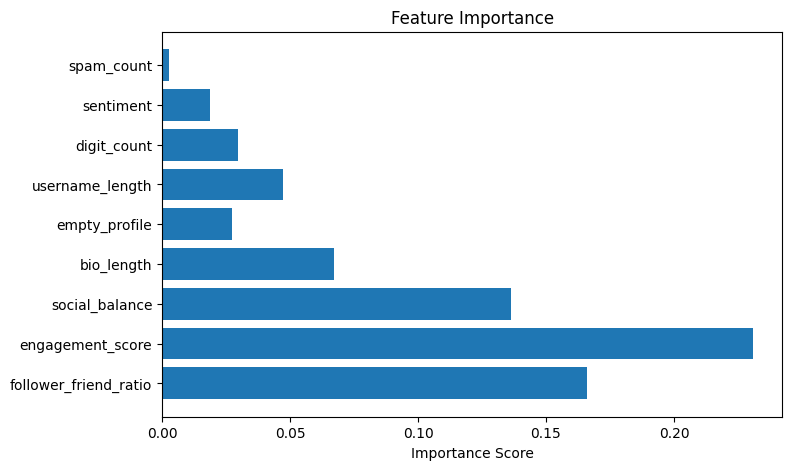

In [107]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_[:9]  # only numeric features
feature_names = X_numeric.columns

plt.figure(figsize=(8,5))
plt.barh(feature_names, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

## STEP 11: Explainability

In [112]:
def explain_prediction(row):
    reasons = []

    if row['spam_count'] > 0:
        reasons.append("Contains spam-like words")

    if row['engagement_score'] < 0.1:
        reasons.append("Low engagement rate")

    if row['follower_friend_ratio'] < 0.5:
        reasons.append("Unbalanced follower-following ratio")

    if row['empty_profile'] == 1:
        reasons.append("Empty profile description")

    # If no issues → mark as normal
    if len(reasons) == 0:
        return ["No suspicious behavior detected"]

    return reasons

In [113]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(tfidf, open("tfidf.pkl", "wb"))

In [114]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pickle

df['description_clean'] = df['description_clean'].fillna('')

X = df[['description_clean',
        'followers_scaled',
        'friends_scaled',
        'favourites_scaled',
        'follower_friend_ratio',
        'engagement_score',
        'bio_length',
        'sentiment',
        'spam_count']]

y = df['label']

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=100), 'description_clean'),
        ('num', 'passthrough', [
            'followers_scaled',
            'friends_scaled',
            'favourites_scaled',
            'follower_friend_ratio',
            'engagement_score',
            'bio_length',
            'sentiment',
            'spam_count'
        ])
    ]
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

model.fit(X, y)

pickle.dump(model, open("model.pkl", "wb"))

In [115]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [117]:
pip install scikit-learn==1.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 32.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn: filename=scikit_learn-1.2.2-cp312-cp312-linux_x86_64.whl size=9452379 sha256=a4973cf0d4ab99602331b3a36973e02fbeef90c262e7d6484367b16b26cc1477
  Stored in directory: /root/.cache/pip/wheels/24/f8/77/ae90c181b806f450a6fec8c8f794594e7c92fa79d7ca27e656
Successfully built scikit-learn
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.11 requires scikit-learn>=1.6, but you have scikit-learn 1.2.2 which is incompatible.
spopt 0.7.0 require